In [14]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

RANDOM_SEED = 32
BEST_NUM_FEATS = 78
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima
    'learning_rate': [.01, .02, .03, .05],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3, 4, 5],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.3, .5, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [0, .1, .5, 1, 5],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [100, 500, 1000],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50, 100, 150, 200],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../data/predict_games/model_features_in/rfe_features.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

np.random.seed(RANDOM_SEED)

In [2]:
# Train is all games before the 2023 season, holdout is 2023
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2021)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2021) & (MODEL_INPUTS_DF['season'] < 2023)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] == 2023].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [3]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [4]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.60035	validation_1-auc:0.60466
[1]	validation_0-auc:0.62909	validation_1-auc:0.63874
[2]	validation_0-auc:0.63956	validation_1-auc:0.64682
[3]	validation_0-auc:0.64713	validation_1-auc:0.64978
[4]	validation_0-auc:0.64896	validation_1-auc:0.65490
[5]	validation_0-auc:0.64794	validation_1-auc:0.65200
[6]	validation_0-auc:0.65116	validation_1-auc:0.65382
[7]	validation_0-auc:0.65339	validation_1-auc:0.65377
[8]	validation_0-auc:0.65283	validation_1-auc:0.65234
[9]	validation_0-auc:0.65697	validation_1-auc:0.65352
[10]	validation_0-auc:0.65850	validation_1-auc:0.65845
[11]	validation_0-auc:0.65888	validation_1-auc:0.65688
[12]	validation_0-auc:0.65794	validation_1-auc:0.65671
[13]	validation_0-auc:0.65990	validation_1-auc:0.65874
[14]	validation_0-auc:0.66010	validation_1-auc:0.65890
[15]	validation_0-auc:0.66235	validation_1-auc:0.66040
[16]	validation_0-auc:0.66476	validation_1-auc:0.66156
[17]	validation_0-auc:0.66493	validation_1-auc:0.66229
[18]	validation_0-au

In [5]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([16.167044  , 16.6292572 , 14.09401226, 11.52176404,  2.09501489,
         8.77125176,  3.8843019 ,  3.8632911 ,  3.56407881,  6.91144355,
         8.70422705,  1.9128627 ,  4.2125024 ,  4.17936095,  6.78289159,
        16.64889654,  8.27113684, 25.63926729,  1.85392467,  3.65906008,
        11.52691189, 13.1205562 ,  1.12394834,  6.85760657,  7.65202403,
         2.44921994,  9.2692186 ,  9.15023359, 11.3399752 ,  4.45582088,
         6.66354521, 12.07405122,  3.50220903,  4.25383814,  3.71945691,
         3.78317936,  4.24524768,  3.71780014,  2.86689409,  1.05491281,
         3.72506865, 13.95363164,  3.9529256 ,  7.84504827,  3.83342727,
         3.40105319,  2.86418239,  5.15821044, 12.67893195, 11.67046491,
         2.58948938, 11.72295006,  2.65142703, 13.69913689, 15.01361696,
         1.70757341,  1.49780329, 11.106824  ,  3.90715837,  3.70013714,
         1.91761518,  3.75444452, 10.63306006,  6.90321867,  4.03774309,
         3.76537657,  8.404821  , 

<Axes: >

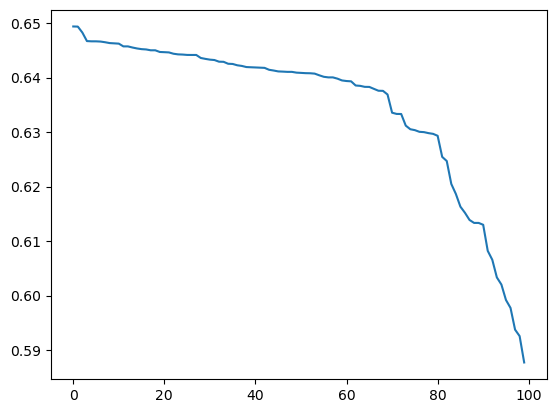

In [6]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()


In [7]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,param_gamma,param_eval_metric,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,18.704001,3.013191,0.045433,0.003763,0.3,1000,50,2,0.01,total_gain,0,auc,150,"{'subsample': 0.3, 'n_estimators': 1000, 'min_...",0.664251,0.610984,0.672854,0.649363,0.027365,1
1,10.633060,4.339871,0.042644,0.006705,0.5,500,20,2,0.03,total_gain,0.1,auc,100,"{'subsample': 0.5, 'n_estimators': 500, 'min_c...",0.663251,0.614905,0.669861,0.649339,0.024498,2
2,13.699137,2.868439,0.057186,0.001167,0.3,500,50,4,0.01,total_gain,1,auc,50,"{'subsample': 0.3, 'n_estimators': 500, 'min_c...",0.663511,0.606813,0.674406,0.648244,0.029631,3
3,8.784439,2.220606,0.035843,0.003927,0.5,1000,20,2,0.05,total_gain,0.1,auc,150,"{'subsample': 0.5, 'n_estimators': 1000, 'min_...",0.661275,0.613583,0.665191,0.646683,0.023460,4
4,6.663545,1.336710,0.038786,0.003207,0.5,500,50,4,0.03,total_gain,1,auc,50,"{'subsample': 0.5, 'n_estimators': 500, 'min_c...",0.662697,0.611060,0.666162,0.646640,0.025198,5


In [8]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [9]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6158088235294118

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2023_01_ARI_WAS,1,ARI,WAS,0,0.499198
1,2023_01_ARI_WAS,1,WAS,ARI,1,0.517117
2,2023_01_BUF_NYJ,1,BUF,NYJ,0,0.538972
3,2023_01_BUF_NYJ,1,NYJ,BUF,1,0.459252
4,2023_01_CAR_ATL,1,CAR,ATL,0,0.469559
...,...,...,...,...,...,...
539,2023_18_PIT_BAL,18,BAL,PIT,0,0.552381
540,2023_18_SEA_ARI,18,ARI,SEA,0,0.474960
541,2023_18_SEA_ARI,18,SEA,ARI,1,0.523013
542,2023_18_TB_CAR,18,TB,CAR,1,0.538518


week
1     0.593750
2     0.441406
3     0.601562
4     0.957031
5     0.362245
6     0.622222
7     0.301775
8     0.695312
9     0.719388
10    0.698980
11    0.862245
12    0.605469
13    0.798817
14    0.453333
15    0.816406
16    0.539062
17    0.730469
18    0.562500
dtype: float64

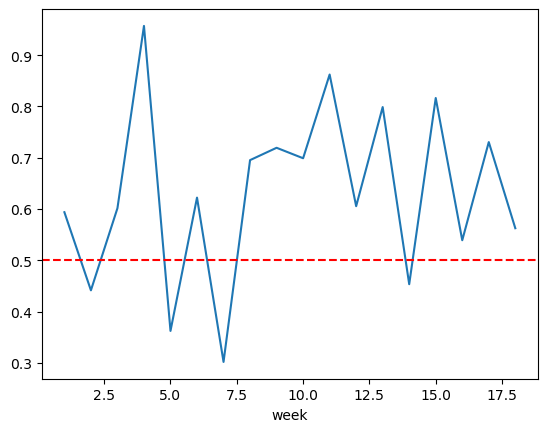

In [15]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [17]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.433333
2     0.460317
3     0.466667
4     0.800000
5     0.354167
6     0.480000
7     0.275000
8     0.509091
9     0.688889
10    0.622222
11    0.825000
12    0.516667
13    0.600000
14    0.321429
15    0.625000
16    0.380952
17    0.654545
18    0.396825
dtype: float64

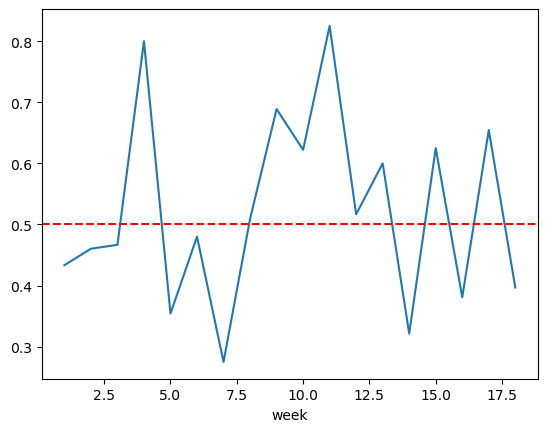

In [18]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores